In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io, color
from skimage.transform import radon, iradon, resize
from numpy.linalg import norm
import scipy.io as sio
import astra
import time

from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
directory = '/content/gdrive/MyDrive/PUB/Otimização Não Linear/small/'

Shape de X_dark: (2560, 30)
Shape de X_flat: (2560, 200)
Shape de X_proj: (2560, 1500)

Após transposição:
X_dark: (30, 2560) (dark_images, detector_pixels)
X_flat: (200, 2560) (flat_images, detector_pixels)
X_proj: (1500, 2560) (projections, detector_pixels)


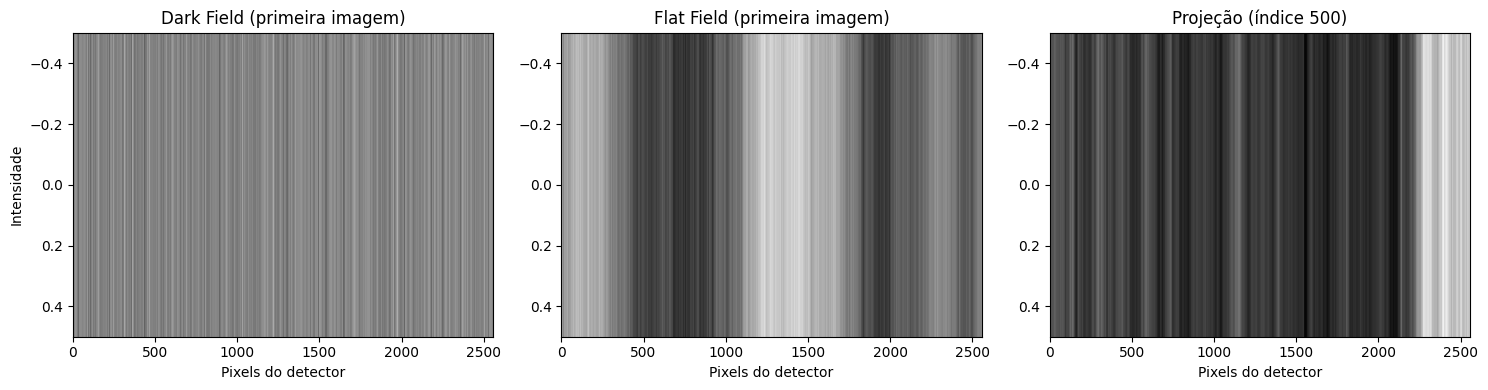

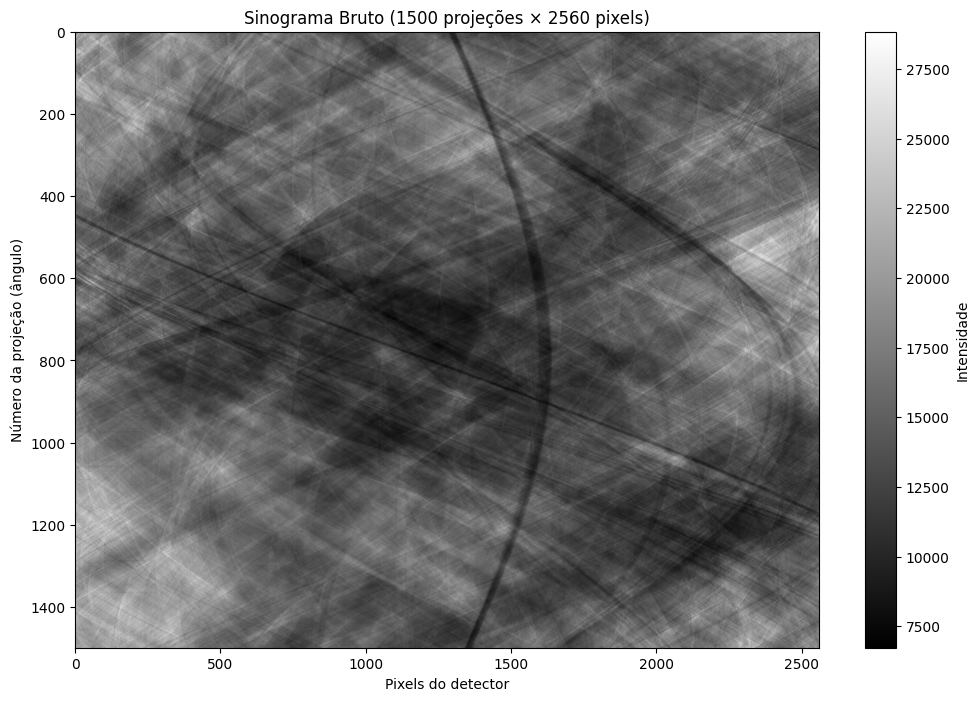


--- Estatísticas dos dados ---
X_dark - min: 75.00, max: 156.00, mean: 109.74
X_flat - min: 42171.00, max: 49472.00, mean: 45445.68
X_proj - min: 6729.00, max: 28840.00, mean: 14730.09

--- Realizando pré-processamento ---
Dark mean shape: (2560,)
Flat mean shape: (2560,)


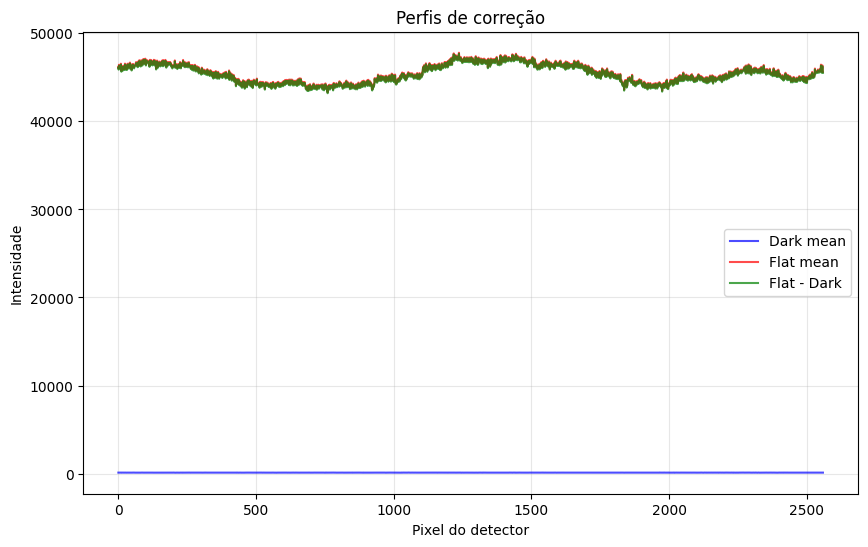

Após correção: min=0.1478, max=0.6269


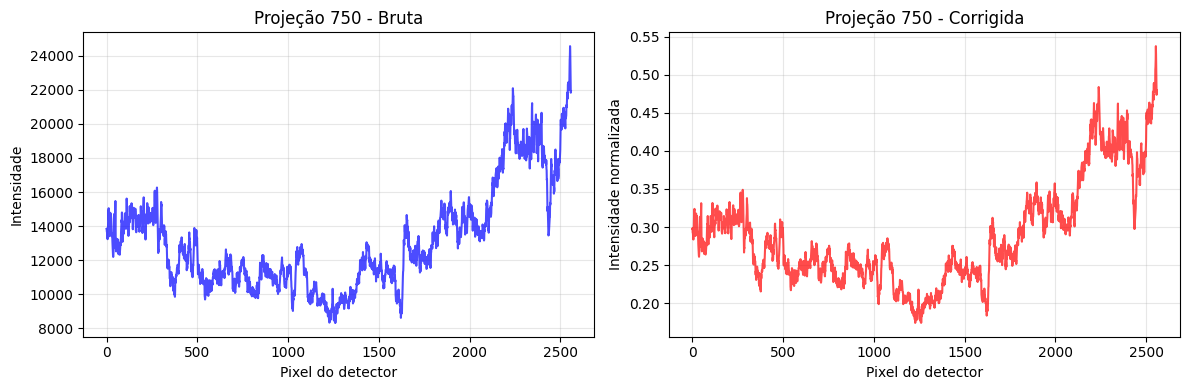


Após -log: min=0.4669, max=1.9116


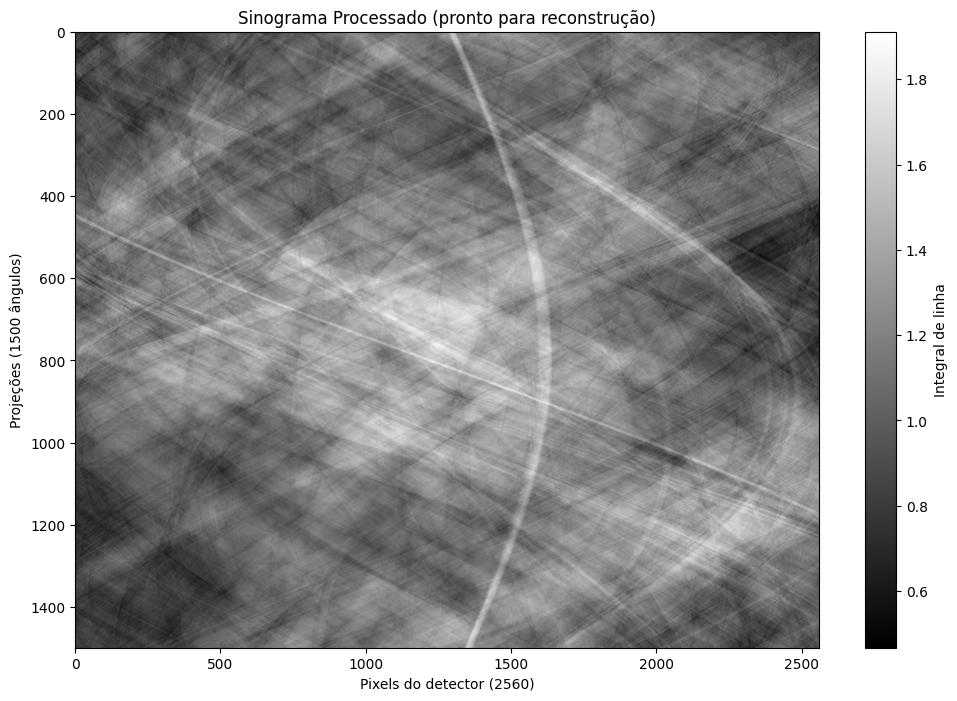


--- Configuração da geometria ---
Detector pixels: 2560
Número de ângulos: 1500
Ângulo entre projeções: 0.1200 graus
Intervalo de ângulos: 0 a 179.88 graus
Sinograma reduzido: (1500, 512)

--- Iniciando reconstrução (isso pode levar alguns minutos) ---
Iteração   0: erro = 2.74e+04, passo = 0.0000
Iteração   5: erro = 1.06e+04, passo = 0.0000
Tempo de reconstrução: 247.96 segundos


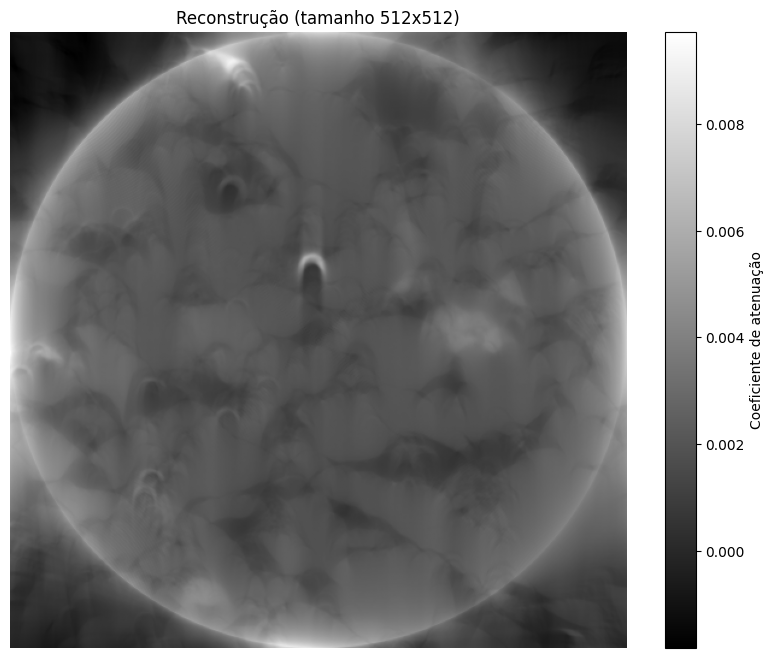

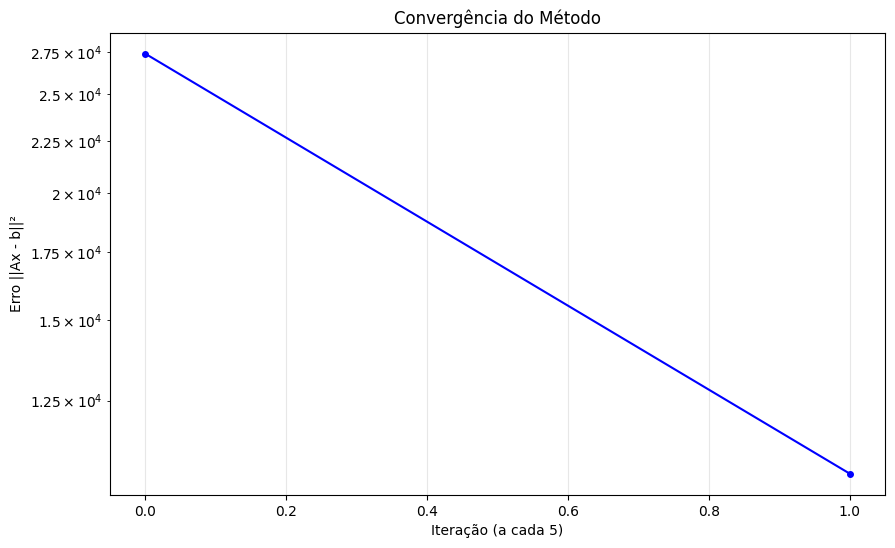

In [ ]:
# 1. Carregar o arquivo .mat
mat_data = sio.loadmat(directory + 'slice_0540_data.mat')

# Extrair os dados
X_dark = mat_data['X_dark']    # Shape: (2560, 30) - (pixels, dark_images)
X_flat = mat_data['X_flat']    # Shape: (2560, 200) - (pixels, flat_images)
X_proj = mat_data['X_proj']    # Shape: (2560, 1500) - (pixels, projections)

print(f"Shape de X_dark: {X_dark.shape}")  # (2560, 30)
print(f"Shape de X_flat: {X_flat.shape}")  # (2560, 200)
print(f"Shape de X_proj: {X_proj.shape}")  # (2560, 1500)

# TRANSPOR para o formato correto: (n_angles, n_detector)
X_dark = X_dark.T      # Agora (30, 2560)
X_flat = X_flat.T      # Agora (200, 2560)
X_proj = X_proj.T      # Agora (1500, 2560)

print(f"\nApós transposição:")
print(f"X_dark: {X_dark.shape} (dark_images, detector_pixels)")
print(f"X_flat: {X_flat.shape} (flat_images, detector_pixels)")
print(f"X_proj: {X_proj.shape} (projections, detector_pixels)")

# 2. Visualizar alguns exemplos (agora funciona!)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(X_dark[0].reshape(1, -1), cmap='gray', aspect='auto')
axes[0].set_title('Dark Field (primeira imagem)')
axes[0].set_xlabel('Pixels do detector')
axes[0].set_ylabel('Intensidade')

axes[1].imshow(X_flat[0].reshape(1, -1), cmap='gray', aspect='auto')
axes[1].set_title('Flat Field (primeira imagem)')
axes[1].set_xlabel('Pixels do detector')

axes[2].imshow(X_proj[500].reshape(1, -1), cmap='gray', aspect='auto')
axes[2].set_title('Projeção (índice 500)')
axes[2].set_xlabel('Pixels do detector')

plt.tight_layout()
plt.show()

# Agora mostrar como imagem 2D (sinograma)
plt.figure(figsize=(12, 8))
plt.imshow(X_proj, cmap='gray', aspect='auto')
plt.title('Sinograma Bruto (1500 projeções × 2560 pixels)')
plt.xlabel('Pixels do detector')
plt.ylabel('Número da projeção (ângulo)')
plt.colorbar(label='Intensidade')
plt.show()

# 3. Verificar estatísticas
print(f"\n--- Estatísticas dos dados ---")
print(f"X_dark - min: {X_dark.min():.2f}, max: {X_dark.max():.2f}, mean: {X_dark.mean():.2f}")
print(f"X_flat - min: {X_flat.min():.2f}, max: {X_flat.max():.2f}, mean: {X_flat.mean():.2f}")
print(f"X_proj - min: {X_proj.min():.2f}, max: {X_proj.max():.2f}, mean: {X_proj.mean():.2f}")

# 4. Pré-processamento (correção de dark e flat)
print("\n--- Realizando pré-processamento ---")

# Calcular médias ao longo das imagens (axis=0)
dark_mean = np.mean(X_dark, axis=0)      # Média dos dark fields (perfil de 2560 pixels)
flat_mean = np.mean(X_flat, axis=0)      # Média dos flat fields (perfil de 2560 pixels)

print(f"Dark mean shape: {dark_mean.shape}")  # (2560,)
print(f"Flat mean shape: {flat_mean.shape}")  # (2560,)

# Visualizar os perfis de correção
plt.figure(figsize=(10, 6))
plt.plot(dark_mean, 'b-', label='Dark mean', alpha=0.7)
plt.plot(flat_mean, 'r-', label='Flat mean', alpha=0.7)
plt.plot(flat_mean - dark_mean, 'g-', label='Flat - Dark', alpha=0.7)
plt.xlabel('Pixel do detector')
plt.ylabel('Intensidade')
plt.title('Perfis de correção')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Corrigir cada projeção: I_corrected = (I_raw - dark) / (flat - dark)
# Adicionar pequeno valor para evitar divisão por zero
denominator = flat_mean - dark_mean
denominator = np.where(denominator < 1e-6, 1e-6, denominator)

sinogram_corrected = np.zeros_like(X_proj, dtype=np.float32)

for i in range(X_proj.shape[0]):
    sinogram_corrected[i] = (X_proj[i] - dark_mean) / denominator

# Clip para evitar valores negativos ou muito pequenos
sinogram_corrected = np.clip(sinogram_corrected, 1e-6, None)

print(f"Após correção: min={sinogram_corrected.min():.4f}, max={sinogram_corrected.max():.4f}")

# Mostrar uma projeção antes e depois
proj_idx = 750  # Meio da varredura
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(X_proj[proj_idx], 'b-', alpha=0.7)
axes[0].set_title(f'Projeção {proj_idx} - Bruta')
axes[0].set_xlabel('Pixel do detector')
axes[0].set_ylabel('Intensidade')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sinogram_corrected[proj_idx], 'r-', alpha=0.7)
axes[1].set_title(f'Projeção {proj_idx} - Corrigida')
axes[1].set_xlabel('Pixel do detector')
axes[1].set_ylabel('Intensidade normalizada')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Aplicar transformada -log para converter em integrais de linha
# Lei de Beer-Lambert: I = I0 * exp(-integral) => integral = -ln(I/I0)
# Onde I0 é a intensidade de referência (flat field médio)

# Usar o flat médio como referência I0 (por pixel)
I0 = flat_mean  # Referência por pixel

# Aplicar -log, garantindo valores positivos
sinogram_processed = -np.log(np.maximum(sinogram_corrected, 1e-8))

print(f"\nApós -log: min={sinogram_processed.min():.4f}, max={sinogram_processed.max():.4f}")

# Visualizar sinograma processado
plt.figure(figsize=(12, 8))
plt.imshow(sinogram_processed, cmap='gray', aspect='auto')
plt.title('Sinograma Processado (pronto para reconstrução)')
plt.xlabel('Pixels do detector (2560)')
plt.ylabel('Projeções (1500 ângulos)')
plt.colorbar(label='Integral de linha')
plt.show()

# 6. Configurar geometria para reconstrução
n_detector = X_proj.shape[1]      # Número de pixels no detector: 2560
n_angles = X_proj.shape[0]        # Número de projeções: 1500

# Ângulos: de 0 a 180 graus (π radianos)
# Nota: 1500 projeções de 0 a 180 graus (excluindo 180)
angles = np.linspace(0, np.pi, n_angles, endpoint=False)

print(f"\n--- Configuração da geometria ---")
print(f"Detector pixels: {n_detector}")
print(f"Número de ângulos: {n_angles}")
print(f"Ângulo entre projeções: {np.rad2deg(angles[1] - angles[0]):.4f} graus")
print(f"Intervalo de ângulos: 0 a {np.rad2deg(angles[-1]):.2f} graus")

# Para reconstrução, podemos reduzir a resolução se necessário
# 2560x2560 pode ser muito grande! Vamos reduzir para 512x512 para teste
recon_size = 512

# Subamostrar o sinograma para tamanho menor
from skimage.transform import resize

sinogram_small = resize(sinogram_processed, (n_angles, recon_size), preserve_range=True)
b = sinogram_small
print(f"Sinograma reduzido: {b.shape}")

# Geometria para ASTRA com tamanho reduzido
vol_geom = astra.create_vol_geom(recon_size, recon_size)
proj_geom = astra.create_proj_geom('parallel', 1.0, recon_size, angles)

# Criar projetor
projector_id = astra.create_projector('linear', proj_geom, vol_geom)

# 7. Definir operadores para seu algoritmo
def A(x):
    _, sinogram = astra.create_sino(x, projector_id)
    return sinogram

def AT(y):
    _, backproj = astra.create_backprojection(y, projector_id)
    return backproj

# 8. Seu método de gradiente descendente
def grad(x):
    Ax = A(x)
    return AT(Ax - b)

def exact_step(x):
    g = grad(x)
    Ag = A(g)
    ATAg = AT(Ag)
    num = np.sum(g * g)
    den = np.sum(g * ATAg)
    return num / den if den > 0 else 0.01

def descent_grad(x0=None, Lambda=None, iters=10, verbose=True):
    if x0 is None:
        x = np.zeros((recon_size, recon_size), dtype=np.float32)
    else:
        x = x0.copy()

    history = []
    errors = []

    for i in range(iters):
        if Lambda is None:
            step = exact_step(x)
        else:
            step = Lambda

        x = x - step * grad(x)

        # Calcular erro a cada iteração
        if verbose and i % 5 == 0:
            Ax = A(x)
            error = 0.5 * np.sum((Ax - b)**2)
            errors.append(error)
            print(f"Iteração {i:3d}: erro = {error:.2e}, passo = {step:.4f}")

    return x, errors
import time
# 9. Executar reconstrução
print("\n--- Iniciando reconstrução (isso pode levar alguns minutos) ---")
start = time.time()
reconstruction, errors = descent_grad(iters=10)
end = time.time()
print(f"Tempo de reconstrução: {end - start:.2f} segundos")
# Visualizar resultado
plt.figure(figsize=(10, 8))
plt.imshow(reconstruction, cmap='gray')
plt.title(f'Reconstrução (tamanho {recon_size}x{recon_size})')
plt.colorbar(label='Coeficiente de atenuação')
plt.axis('off')
plt.show()

# Mostrar evolução do erro
plt.figure(figsize=(10, 6))
plt.semilogy(errors, 'b-o', markersize=4)
plt.xlabel('Iteração (a cada 5)')
plt.ylabel('Erro ||Ax - b||²')
plt.title('Convergência do Método')
plt.grid(True, alpha=0.3)
plt.show()